<a href="https://colab.research.google.com/github/hassan1662n/Deep-learning-projects/blob/main/Dog_vs_Cat_Classification_using_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import json
import os

# 1. PASTE YOUR COPIED NETWORKING KEY TEXT DIRECTLY BETWEEN THE CURLY BRACES BELOW:
api_token = {"username":"hassan1662","key":"KGAT_22152007038f7449e1bbcbd7a0065cce"}

# 2. This code automatically builds the hidden folder and writes your key file into it
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as file:
    json.dump(api_token, file)

# 3. Secure the file permissions automatically
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

print("Kaggle API successfully configured!")


Kaggle API successfully configured!


In [3]:
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset

Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
kaggle-cat-vs-dog-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:

!unzip -q kaggle-cat-vs-dog-dataset.zip -d /content/cats-dogs

replace /content/cats-dogs/kagglecatsanddogs_3367a/MSR-LA - 3467.docx? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A



In [5]:
!find /content/cats-dogs -maxdepth 3 -type d

/content/cats-dogs
/content/cats-dogs/kagglecatsanddogs_3367a
/content/cats-dogs/kagglecatsanddogs_3367a/PetImages
/content/cats-dogs/kagglecatsanddogs_3367a/PetImages/Dog
/content/cats-dogs/kagglecatsanddogs_3367a/PetImages/Cat


In [6]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

In [8]:
import os
base_path = "/content/cats-dogs/kagglecatsanddogs_3367a"

pet_images_path = base_path + "/PetImages"

cat_dir = pet_images_path + "/Cat"
dog_dir = pet_images_path + "/Dog"

print(cat_dir)
print(dog_dir)

/content/cats-dogs/kagglecatsanddogs_3367a/PetImages/Cat
/content/cats-dogs/kagglecatsanddogs_3367a/PetImages/Dog


In [9]:
print(len(os.listdir(cat_dir)))
print(len(os.listdir(dog_dir)))

12491
12470


In [10]:
import cv2
import numpy as np
import os

X = []
Y = []

limit = 3000  # safe limit

def load_images(folder, label):
    count = 0

    for img_name in os.listdir(folder):
        if count >= limit:
            break

        img_path = os.path.join(folder, img_name)

        try:
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (128, 128))
            X.append(img)
            Y.append(label)
            count += 1

        except:
            continue

In [11]:
load_images(cat_dir, 0)
load_images(dog_dir, 1)

In [12]:
print("X:", len(X))
print("Y:", len(Y))

X: 6000
Y: 6000


In [13]:
X = []
Y = []

limit = 5000   # 👈 IMPORTANT (prevents crash)

count = 0

for img_name in os.listdir(cat_dir):
    if count >= limit:
        break
    img_path = os.path.join(cat_dir, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (128, 128))
        X.append(img)
        Y.append(0)
        count += 1

In [14]:
count = 0

for img_name in os.listdir(dog_dir):
    if count >= limit:
        break
    img_path = os.path.join(dog_dir, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (128, 128))
        X.append(img)
        Y.append(1)
        count += 1

In [15]:
print("Number of Cat Images:", len(os.listdir(cat_dir)))
print("Number of Dog Images:", len(os.listdir(dog_dir)))

Number of Cat Images: 12491
Number of Dog Images: 12470


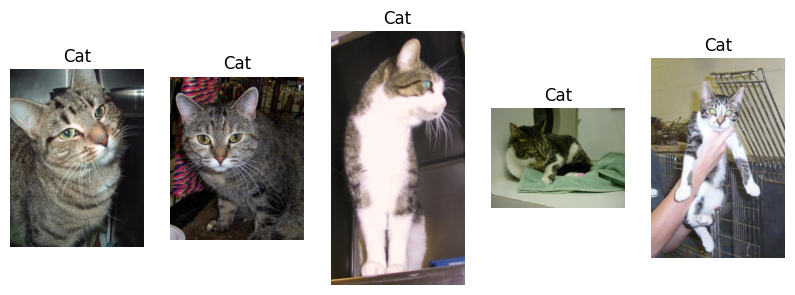

In [16]:
import matplotlib.pyplot as plt
import cv2

cat_files = os.listdir(cat_dir)

plt.figure(figsize=(10,5))

for i in range(5):
    img_path = os.path.join(cat_dir, cat_files[i])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title("Cat")
    plt.axis("off")

plt.show()


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [18]:
print(X_train[0].shape)
print(X_train[0])

(128, 128, 3)
[[[197 255 252]
  [206 254 252]
  [203 254 252]
  ...
  [ 59 166  76]
  [ 39 144  29]
  [ 33 130  12]]

 [[205 255 253]
  [211 254 253]
  [207 255 253]
  ...
  [ 53 138  52]
  [ 62 144  53]
  [ 40 123  21]]

 [[213 255 254]
  [215 255 254]
  [210 255 254]
  ...
  [ 27  97   3]
  [ 41 110  20]
  [ 43 119  40]]

 ...

 [[ 63 157  41]
  [ 31 112  16]
  [ 26  96  21]
  ...
  [ 35  98  41]
  [ 54 122  64]
  [ 67 153  76]]

 [[ 53 137  34]
  [ 13  83   7]
  [ 33  96  36]
  ...
  [ 76 131  78]
  [ 77 150  89]
  [ 78 163  89]]

 [[ 51 133  25]
  [ 57 125  39]
  [ 77 141  69]
  ...
  [111 166 112]
  [ 84 171  99]
  [ 52 138  50]]]


In [19]:
print("Train:", len(X_train), len(Y_train))
print("Test:", len(X_test), len(Y_test))

Train: 8000 8000
Test: 2000 2000


In [20]:
import numpy as np

X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)

Y_train = np.asarray(Y_train, dtype=np.float32)
Y_test = np.asarray(Y_test, dtype=np.float32)

Y_train = Y_train.reshape(-1, 1)
Y_test = Y_test.reshape(-1, 1)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [23]:
import tensorflow as tf

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [25]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

this is train from scratch

In [28]:
history = model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.6190 - loss: 0.9891 - val_accuracy: 0.5105 - val_loss: 1.1299
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.6873 - loss: 0.6065 - val_accuracy: 0.6270 - val_loss: 0.6511
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 435s 2s/step - accuracy: 0.7209 - loss: 0.5546 - val_accuracy: 0.6810 - val_loss: 0.8869
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.7646 - loss: 0.4877 - val_accuracy: 0.7060 - val_loss: 0.6248
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - accuracy: 0.7933 - loss: 0.4456 - val_accuracy: 0.7260 - val_loss: 0.5361
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 428s 2s/step - accuracy: 0.8115 - loss: 0.4086 - val_accuracy: 0.7885 - val_loss: 0.4632
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.8356 - loss: 0.3659 - val_accuracy: 0.6445 - val_loss: 0.8532
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - accuracy: 0.8521 - loss: 0.3355 - val_accu

In [29]:
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 344ms/step - accuracy: 0.7860 - loss: 0.4823
Test Loss: 0.48226311802864075
Test Accuracy: 0.7860000133514404


In [30]:
import numpy as np

pred = model.predict(X_test)
pred = (pred > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 337ms/step


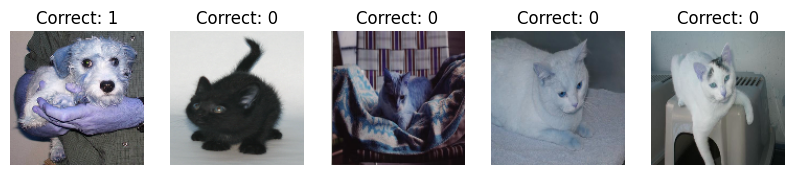

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

count = 0
for i in range(len(X_test)):
    if pred[i] == Y_test[i]:
        plt.subplot(1,5,count+1)
        plt.imshow(X_test[i])
        plt.title(f"Correct: {pred[i][0]}")
        plt.axis("off")
        count += 1
    if count == 5:
        break
plt.show()

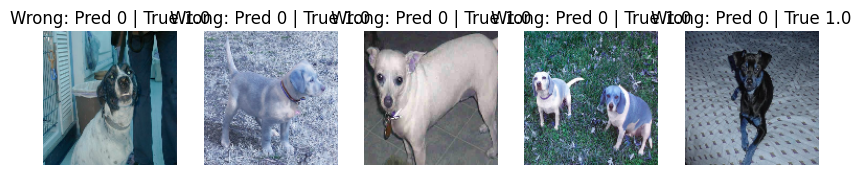

In [32]:
plt.figure(figsize=(10,5))

count = 0
for i in range(len(X_test)):
    if pred[i] != Y_test[i]:
        plt.subplot(1,5,count+1)
        plt.imshow(X_test[i])
        plt.title(f"Wrong: Pred {pred[i][0]} | True {Y_test[i][0]}")
        plt.axis("off")
        count += 1
    if count == 5:
        break

plt.show()

Transfer Learning using MobileNetV2

In [33]:
import tensorflow as tf
import tensorflow_hub as hub

In [35]:
mobilenet_model = 'https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [40]:
num_of_classes = 1 # Binary classification (cat or dog), so 1 output unit

# Define the input layer with the actual shape of your data
inputs = tf.keras.Input(shape=(128, 128, 3))

# Resize images to the size expected by MobileNetV2 (224x224)
x = tf.keras.layers.Resizing(224, 224)(inputs)

# Pass the resized input through the pre-trained MobileNetV2 model
# Workaround: Wrap the KerasLayer in a Lambda layer to ensure symbolic execution
x = tf.keras.layers.Lambda(lambda tensor: pretrained_model(tensor))(x)

# Add a final Dense layer for classification
outputs = tf.keras.layers.Dense(num_of_classes, activation='sigmoid')(x) # Sigmoid for binary classification

# Create the model using the Functional API
model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False), # Explicitly setting from_logits=False
    metrics=['accuracy']
)

In [44]:
model.fit(X_train, Y_train, epochs=5)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.9489 - loss: 0.1347
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 299s 1s/step - accuracy: 0.9779 - loss: 0.0634
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.9812 - loss: 0.0543
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.9837 - loss: 0.0479
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.9861 - loss: 0.0440


In [46]:
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9785 - loss: 0.0582
Test Loss: 0.05820915848016739
Test Accuracy: 0.9785000085830688


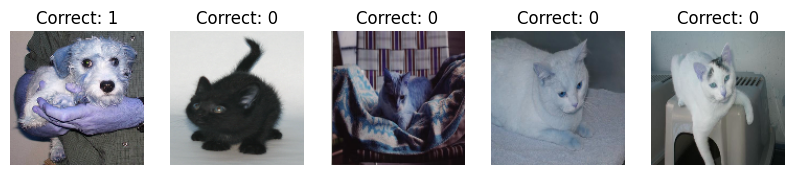

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

count = 0
for i in range(len(X_test)):
    if pred[i] == Y_test[i]:
        plt.subplot(1,5,count+1)
        plt.imshow(X_test[i])
        plt.title(f"Correct: {pred[i][0]}")
        plt.axis("off")
        count += 1
    if count == 5:
        break
plt.show()

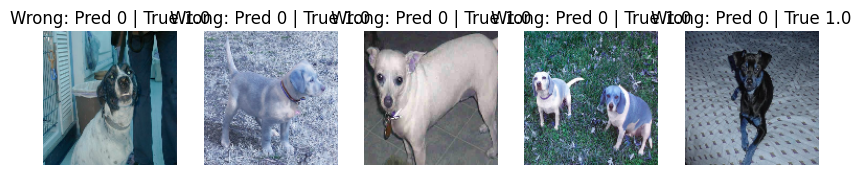

In [48]:
plt.figure(figsize=(10,5))

count = 0
for i in range(len(X_test)):
    if pred[i] != Y_test[i]:
        plt.subplot(1,5,count+1)
        plt.imshow(X_test[i])
        plt.title(f"Wrong: Pred {pred[i][0]} | True {Y_test[i][0]}")
        plt.axis("off")
        count += 1
    if count == 5:
        break

plt.show()